Preliminary MC with Memory

In [1]:
import random
from collections import defaultdict

class MemoryGolfSimulator:
    def __init__(self, transition_matrix, start_state, end_states, memory=1):
        """
        transition_matrix: dict mapping (history_state) -> { next_state: prob }
            e.g., ("Tee", "Fairway"): {"Green": 0.7, "Rough": 0.3}
        start_state: tuple of starting states of length `memory`
        end_states: absorbing states (like "Hole")
        memory: how many previous shots define the current state
        """
        self.transition_matrix = transition_matrix
        self.start_state = tuple(start_state)
        self.end_states = set(end_states)
        self.memory = memory

    def next_state(self, history):
        """Choose the next state based on probabilities for the history tuple."""
        transitions = self.transition_matrix[tuple(history)]
        states, probs = zip(*transitions.items())
        return random.choices(states, probs)[0]

    def simulate_round(self, max_shots=20):
        """Simulate a hole until reaching an end state."""
        shots = list(self.start_state)

        for _ in range(max_shots):
            history = tuple(shots[-self.memory:])  # last `memory` states
            nxt = self.next_state(history)
            shots.append(nxt)
            if nxt in self.end_states:
                break
        return shots


# Example: 2nd-order Markov chain (memory = 1 previous shot)
transition_matrix = {
    # From Tee
    ("Tee",): {"Fairway": 0.6, "Rough": 0.25, "Bunker": 0.1, "Green": 0.05},

    # From Fairway
    ("Fairway",): {"Green": 0.5, "Rough": 0.2, "Bunker": 0.2, "Fairway": 0.1},

    # From Rough
    ("Rough",): {"Green": 0.3, "Fairway": 0.4, "Bunker": 0.2, "Rough": 0.1},

    # From Bunker
    ("Bunker",): {"Green": 0.4, "Rough": 0.3, "Fairway": 0.2, "Bunker": 0.1},

    # From Green
    ("Green",): {"Hole": 0.4, "Green": 0.6},

    # From Hole (absorbing)
    ("Hole",): {"Hole": 1.0},
}

# Initialize simulator with memory=1 (previous shot matters)
sim = MemoryGolfSimulator(
    transition_matrix=transition_matrix,
    start_state=("Tee",),
    end_states=["Hole"],
    memory=1
)

# Run a few rounds
for i in range(5):
    result = sim.simulate_round()
    print(f"Round {i+1}: {result}")


Round 1: ['Tee', 'Rough', 'Fairway', 'Rough', 'Bunker', 'Green', 'Green', 'Hole']
Round 2: ['Tee', 'Fairway', 'Rough', 'Green', 'Green', 'Green', 'Green', 'Hole']
Round 3: ['Tee', 'Fairway', 'Bunker', 'Green', 'Green', 'Green', 'Green', 'Hole']
Round 4: ['Tee', 'Fairway', 'Green', 'Hole']
Round 5: ['Tee', 'Fairway', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Hole']


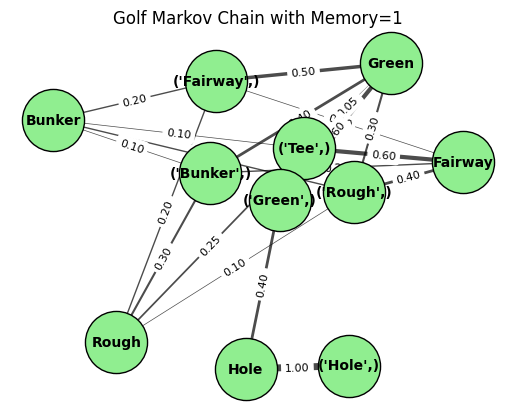

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_markov_chain(transition_matrix, title="Golf Markov Chain"):
    """
    Visualize the Markov chain with states and transition probabilities.
    """
    G = nx.DiGraph()

    # Add edges with weights
    for state, transitions in transition_matrix.items():
        for nxt, prob in transitions.items():
            if prob > 0:  # avoid clutter
                G.add_edge(state, nxt, weight=prob, label=f"{prob:.2f}")

    # Layout
    pos = nx.spring_layout(G, seed=42, k=1.0)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightgreen", edgecolors="black")

    # Draw edges with widths proportional to probabilities
    edges = G.edges(data=True)
    nx.draw_networkx_edges(G, pos, edgelist=edges,
                           width=[d["weight"] * 5 for (_, _, d) in edges],
                           alpha=0.7, arrows=True)

    # Labels for states
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

    # Edge labels (probabilities)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.show()


# Example: visualize the same transition matrix we used earlier
transition_matrix = {
    ("Tee",): {"Fairway": 0.6, "Rough": 0.25, "Bunker": 0.1, "Green": 0.05},
    ("Fairway",): {"Green": 0.5, "Rough": 0.2, "Bunker": 0.2, "Fairway": 0.1},
    ("Rough",): {"Green": 0.3, "Fairway": 0.4, "Bunker": 0.2, "Rough": 0.1},
    ("Bunker",): {"Green": 0.4, "Rough": 0.3, "Fairway": 0.2, "Bunker": 0.1},
    ("Green",): {"Hole": 0.4, "Green": 0.6},
    ("Hole",): {"Hole": 1.0},
}

visualize_markov_chain(transition_matrix, "Golf Markov Chain with Memory=1")
